In [ ]:
# Import libraries

In [1]:
import pandas as pd
import numpy as np

In [ ]:
# Import libraries

In [2]:
df = pd.read_csv(r"C:\Users\abhis\Downloads\Data_Analytics_Projects\Data Analysis\01_raw_data\Marketing.csv")
df.head()

,id,c_date,campaign_name,category,campaign_id,impressions,mark_spent,clicks,leads,orders,revenue
0,1,2021-02-01,facebook_tier1,social,349043,148263,7307.37,1210,13,1,4981.0
1,2,2021-02-01,facebOOK_tier2,social,348934,220688,16300.20,1640,48,3,14962.0
2,3,2021-02-01,google_hot,search,89459845,22850,5221.60,457,9,1,7981.0
3,4,2021-02-01,google_wide,search,127823,147038,6037.00,1196,24,1,2114.0
4,5,2021-02-01,youtube_blogger,influencer,10934,225800,29962.20,2258,49,10,84490.0


In [ ]:
# Handle missing values

In [3]:
df.isnull().sum()

df = df.dropna()

In [11]:
df['CTR'] = df['clicks'] / df['impressions']
df['ROI'] = (df['revenue'] - df['mark_spent']) / df['mark_spent']

In [ ]:
# Remove duplicates

In [4]:
df = df.drop_duplicates()

In [ ]:
# Fix data types

In [6]:
df['date'] = pd.to_datetime(df['c_date'])

In [17]:
# Create new metrics

In [20]:
df['CTR'] = df['clicks'] / df['impressions']

df['Conversion_Rate'] = df['orders'] / df['clicks'].replace(0, 1)

df['ROI'] = (df['revenue'] - df['mark_spent']) / df['mark_spent'].replace(0, 1)

In [21]:
# Handle outliers

In [24]:
df.columns

Index(['id', 'c_date', 'campaign_name', 'category', 'campaign_id',
       'impressions', 'mark_spent', 'clicks', 'leads', 'orders', 'revenue',
       'date', 'CTR', 'Conversion_Rate', 'ROI'],
      dtype='str')

In [26]:
df = df[df['mark_spent'] > 0]
df = df[df['impressions'] > 0]

In [29]:
# Data Analysis using Python

In [30]:
df.describe()

,id,campaign_id,impressions,mark_spent,clicks,leads,orders,revenue,date,CTR,Conversion_Rate,ROI
count,308.000000,3.080000e+02,3.080000e+02,308.000000,308.000000,308.000000,308.000000,3.080000e+02,308,308.000000,308.000000,308.000000
mean,154.500000,9.605628e+06,5.122475e+06,99321.038377,9739.996753,212.918831,26.113636,1.392512e+05,2021-02-14 12:00:00,0.009592,0.002792,0.407612
min,1.000000,1.093400e+04,6.670000e+02,169.750000,20.000000,0.000000,0.000000,0.000000e+00,2021-02-01 00:00:00,0.000079,0.000000,-1.000000
25%,77.750000,1.278230e+05,1.479568e+05,9465.195000,1347.250000,20.750000,3.000000,8.580000e+03,2021-02-07 18:00:00,0.005000,0.001385,-0.318841
50%,154.500000,3.747540e+05,6.028100e+05,36765.150000,4349.500000,84.000000,9.000000,3.891700e+04,2021-02-14 12:00:00,0.006916,0.002590,0.105578
75%,231.250000,4.387490e+06,3.254450e+06,129372.250000,13499.250000,270.500000,29.250000,1.370492e+05,2021-02-21 06:00:00,0.011083,0.003766,0.760220
max,308.000000,8.945984e+07,4.199700e+08,880357.000000,61195.000000,1678.000000,369.000000,2.812520e+06,2021-02-28 00:00:00,0.033556,0.015152,5.593987
std,89.056162,2.543040e+07,2.631134e+07,144008.011181,12157.476244,300.459978,42.741288,2.763031e+05,NaN,0.008222,0.001983,1.217706


In [31]:
# Campaign performance

In [32]:
df.groupby('campaign_name')['ROI'].mean().sort_values(ascending=False)

campaign_name
youtube_blogger         3.068700
facebook_retargeting    1.450263
google_hot              0.708653
instagram_tier1         0.645921
instagram_blogger       0.331378
banner_partner          0.242261
facebook_tier1         -0.066376
facebOOK_tier2         -0.290848
google_wide            -0.325826
instagram_tier2        -0.399501
facebook_lal           -0.880898
Name: ROI, dtype: float64

In [33]:
# Channel performance

In [34]:
df.groupby('category')[['CTR','Conversion_Rate','ROI']].mean()

,CTR,Conversion_Rate,ROI
category,,,
influencer,0.009834,0.004062,1.700039
media,0.001290,0.003361,0.242261
search,0.012297,0.002467,0.191414
social,0.009994,0.002382,0.076427


In [35]:
# Time trend

<Axes: xlabel='date'>

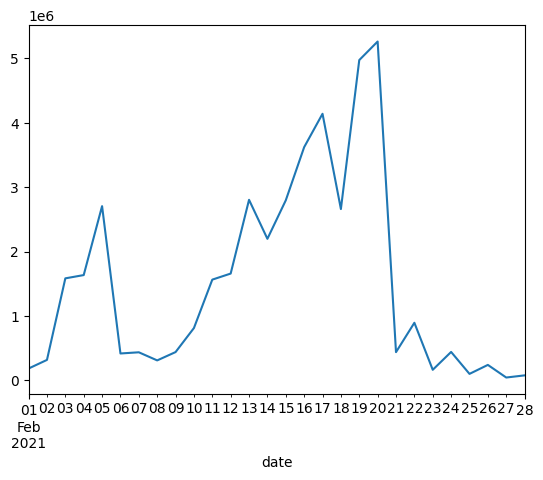

In [36]:
df.groupby('date')['revenue'].sum().plot()

In [27]:
# Export clean dataset

In [37]:
df.to_csv(r"C:\Users\abhis\Downloads\Data_Analytics_Projects\Data Analysis\02_clean_data\Marketing_Campaign.csv", index=False)